<a href="https://colab.research.google.com/github/asommula-code/PRODIGY_ML_05/blob/main/PRODIGY_ML_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub tensorflow opencv-python matplotlib seaborn scikit-learn pillow

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.preprocessing import image

from google.colab import files
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("dansbecker/food-101")

print("Dataset Downloaded At:", path)

Using Colab cache for faster access to the 'food-101' dataset.
Dataset Downloaded At: /kaggle/input/food-101


In [ ]:
path = kagglehub.dataset_download("dansbecker/food-101")

print("Dataset Downloaded At:")
print(path)

Using Colab cache for faster access to the 'food-101' dataset.
Dataset Downloaded At:
/kaggle/input/food-101


In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101/images"

print(DATASET_PATH)

/root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101/images


In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101/images"

In [ ]:
DATASET_PATH = "/kaggle/input/food-101/food-101/food-101/images"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 2

In [ ]:
SELECTED_CLASSES = [
    'apple_pie',
    'cheesecake',
    'fried_rice',
    'hamburger',
    'hot_dog',
    'ice_cream',
    'pizza',
    'spaghetti_bolognese',
    'sushi',
    'waffles'
]


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    classes=SELECTED_CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    classes=SELECTED_CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 8000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)

x = Dropout(0.3)(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

predictions = Dense(10, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,839,341 (18.46 MB)

 Trainable params: 789,770 (3.01 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)


In [ ]:
import os

print(f"Current DATASET_PATH causing the error: {DATASET_PATH}")
print(f"Contents of the base dataset directory ({path}):")
try:
    print(os.listdir(path))
except FileNotFoundError as e:
    print(f"Error listing contents of {path}: {e}")


Current DATASET_PATH causing the error: /kaggle/input/food-101/food-101/images
Contents of the base dataset directory (/kaggle/input/food-101):
['food-101.zip', 'food-101']


In [ ]:
SELECTED_CLASSES = [
    'pizza',
    'hamburger',
    'ice_cream',
    'sushi',
    'apple_pie',
    'hot_dog',
    'waffles',
    'cheesecake',
    'fried_rice',
    'spaghetti_bolognese'
]

In [ ]:
import os

print(os.listdir("/kaggle/input/food-101/food-101"))

['__MACOSX', 'food-101']


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 250s 879ms/step - accuracy: 0.0940 - loss: 2.3189 - val_accuracy: 0.1000 - val_loss: 2.3031 - learning_rate: 0.0010
Epoch 2/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 559ms/step - accuracy: 0.0925 - loss: 2.3031 - val_accuracy: 0.1000 - val_loss: 2.3026 - learning_rate: 0.0010


In [ ]:
model.save("food_recognition_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


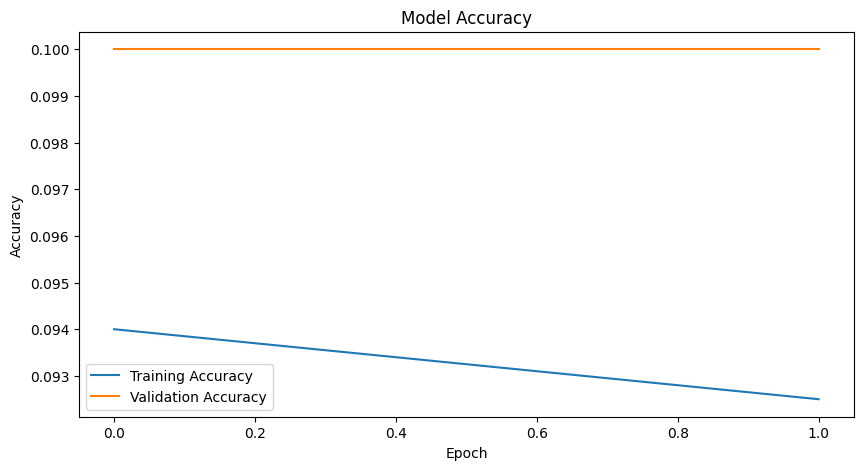

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

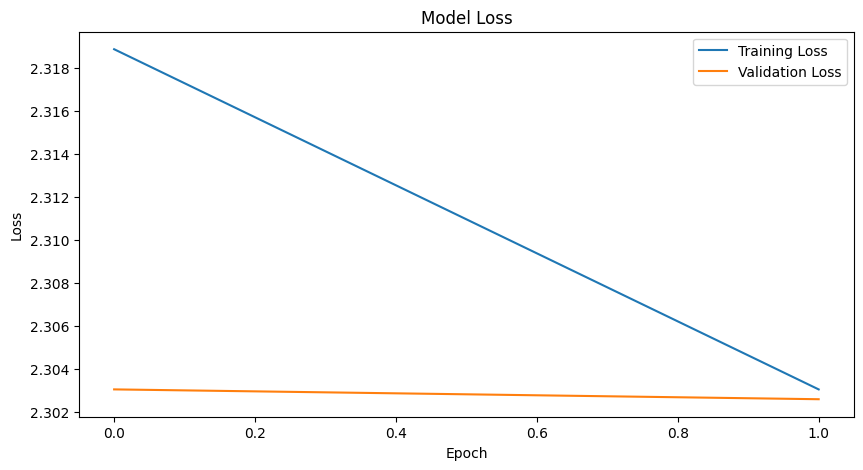

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 550ms/step


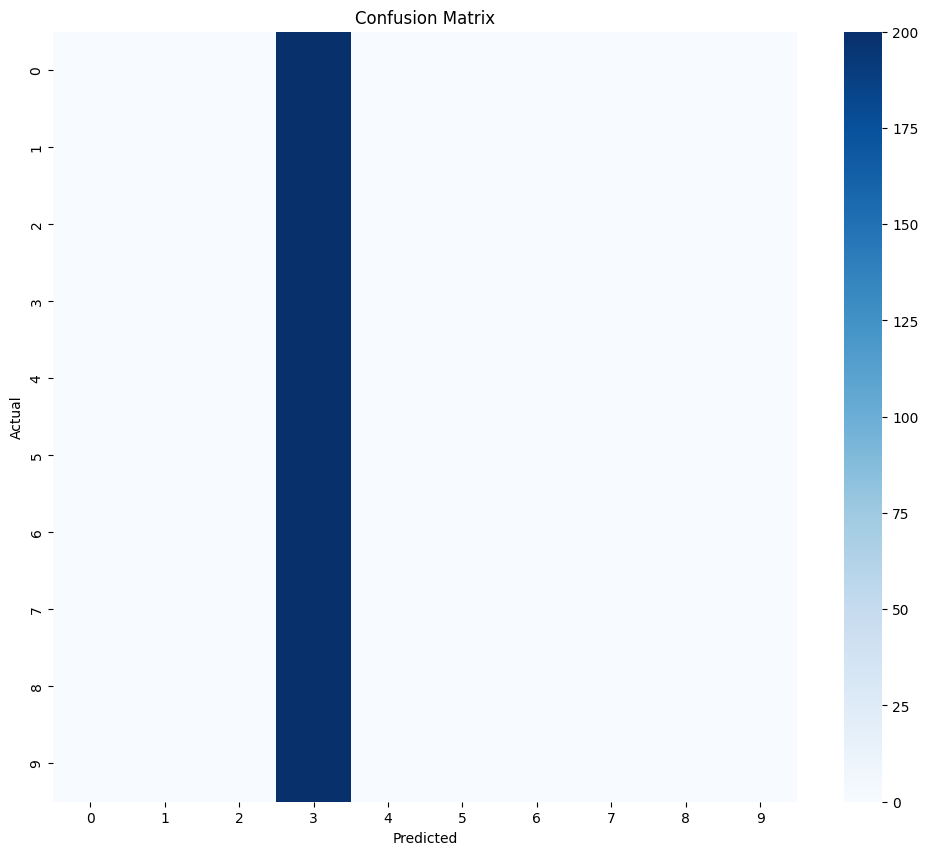

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

                     precision    recall  f1-score   support

          apple_pie       0.00      0.00      0.00       200
         cheesecake       0.00      0.00      0.00       200
         fried_rice       0.00      0.00      0.00       200
          hamburger       0.10      1.00      0.18       200
            hot_dog       0.00      0.00      0.00       200
          ice_cream       0.00      0.00      0.00       200
              pizza       0.00      0.00      0.00       200
spaghetti_bolognese       0.00      0.00      0.00       200
              sushi       0.00      0.00      0.00       200
            waffles       0.00      0.00      0.00       200

           accuracy                           0.10      2000
          macro avg       0.01      0.10      0.02      2000
       weighted avg       0.01      0.10      0.02      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
food_calories = {
    "pizza": 285,
    "hamburger": 295,
    "apple_pie": 237,
    "ice_cream": 207,
    "fried_rice": 163,
    "sushi": 200,
    "donuts": 452,
    "omelette": 154,
    "waffles": 291,
    "hot_dog": 290
}

In [ ]:
uploaded = files.upload()

Saving dataset-cover.jpg to dataset-cover.jpg


In [ ]:
class_names = list(train_generator.class_indices.keys())

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [ ]:
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

food_name = class_names[predicted_index]

confidence = np.max(prediction) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


In [ ]:
estimated_calories = food_calories.get(
    food_name,
    "Calories Data Not Available"
)

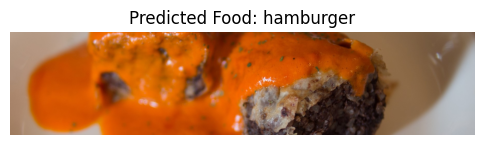

Predicted Food Item: hamburger
Prediction Confidence: 10.11%
Estimated Calories: 295


In [ ]:
display_image = Image.open(img_path)

plt.figure(figsize=(6,6))

plt.imshow(display_image)

plt.axis("off")

plt.title(f"Predicted Food: {food_name}")

plt.show()

print("Predicted Food Item:", food_name)

print("Prediction Confidence: {:.2f}%".format(confidence))

print("Estimated Calories:", estimated_calories)

In [ ]:
import json

with open("class_labels.json", "w") as f:
    json.dump(class_names, f)

print("Class labels saved.")

Class labels saved.


In [ ]:
files.download("food_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>